<a href="https://colab.research.google.com/github/Recollectionss/University/blob/main/4-course/sem-2/miod/lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 1.1 Завантаження датасету
# =========================================

print("\n--- 1.1 Завантаження датасету ---")

df = pd.read_csv(
    "PS_2026.03.12_06.04.19.csv",
    comment='#'
)

df = df.head(10000)


--- 1.1 Завантаження датасету ---


In [ ]:
# =========================================
# 1.2 Видалення зайвих колонок
# =========================================

print("\n--- 1.2 Вибір необхідних колонок ---")

columns = [
    'pl_name',          # назва планети
    'hostname',         # назва зорі
    'discoverymethod',  # метод відкриття
    'disc_year',        # рік відкриття
    'pl_orbper',        # орбітальний період
    'pl_rade',          # радіус планети
    'st_teff'           # температура зорі
]

df = df[columns]

print("Перші 5 рядків після видалення зайвих колонок:")
print(df.head())




--- 1.2 Вибір необхідних колонок ---
Перші 5 рядків після видалення зайвих колонок:
                       pl_name                 hostname  discoverymethod  \
29     1RXS J160929.1-210524 b    1RXS J160929.1-210524          Imaging   
37   2MASS J01225093-2439505 b  2MASS J01225093-2439505          Imaging   
39   2MASS J02192210-3925225 b  2MASS J02192210-3925225          Imaging   
116                   55 Cnc e                   55 Cnc  Radial Velocity   
118                   55 Cnc e                   55 Cnc  Radial Velocity   

     disc_year  pl_orbper   pl_rade  st_teff  
29        2008        NaN  18.64700   4060.0  
37        2013        NaN  11.20900   3309.0  
39        2015        NaN  16.14096   3064.0  
116       2004   0.736546   2.17300   5250.0  
118       2004   0.736540   2.00000      NaN  


In [ ]:
# =========================================
# 1.3 Видалення пропущених значень
# =========================================

print("\n--- 1.3 Видалення рядків з NaN у pl_rade ---")

df = df.dropna(subset=['pl_rade'])

print("Кількість записів після очищення:", len(df))


--- 1.3 Видалення рядків з NaN у pl_rade ---
Кількість записів після очищення: 5426


In [ ]:
# =========================================
# 1.4 Форматування даних
# =========================================

print("\n--- 1.4 Форматування даних ---")

df['disc_year'] = df['disc_year'].astype(int)

print("Тип даних disc_year:", df['disc_year'].dtype)


--- 1.4 Форматування даних ---
Тип даних disc_year: int64


In [ ]:
# =========================================
# 2.1 Загальна кількість рядків
# =========================================

print("\n--- 2.1 Кількість записів у DataFrame ---")

print("Кількість записів:", len(df))


--- 2.1 Кількість записів у DataFrame ---
Кількість записів: 5426


In [ ]:
# =========================================
# 2.2 Робота з числовими показниками
# =========================================

print("\n--- 2.2 Аналіз великих планет ---")

# фільтр планет з великим радіусом
large_planets = df[df['pl_rade'] > 2]

print(f"Кількість планет з радіусом > 2 Earth radii: {len(large_planets)}")

# середній орбітальний період
avg_orbit = large_planets['pl_orbper'].mean()

print(f"Середній орбітальний період: {avg_orbit} днів")


# 10 найбільших планет
top10 = df.sort_values(by='pl_rade', ascending=False).head(10)

print("\n10 планет з найбільшим радіусом:")

print(
    top10[['pl_name', 'pl_rade', 'pl_orbper']]
    .rename(columns={
        'pl_name': 'Planet',
        'pl_rade': 'Radius (Earth radii)',
        'pl_orbper': 'Orbital period (days)'
    })
)



--- 2.2 Аналіз великих планет ---
Кількість планет з радіусом > 2 Earth radii: 3515
Середній орбітальний період: 123767.79267006293 днів

10 планет з найбільшим радіусом:
           Planet  Radius (Earth radii)  Orbital period (days)
6787  KOI-2513.01              103.2300              19.005372
6788  KOI-2513.01              103.2300              19.005372
6786  KOI-2513.01              103.2300              19.005372
1919  HD 100546 b               77.3421                    NaN
6729  KOI-1599.02               64.0500              13.616346
6726  KOI-1599.02               64.0500              13.616346
6727  KOI-1599.02               64.0500              13.616346
962      GQ Lup b               51.5614                    NaN
5441      K2-31 b               46.0000               1.257849
1462   HAT-P-54 b               40.0000               3.800010


In [ ]:
# =========================================
# 2.3 Дослідження категорій
# =========================================

print("\n--- 2.3 Аналіз категоріальних даних ---")

transit = df[df['discoverymethod'] == 'Transit']
print("Кількість планет відкритих методом Transit:", len(transit))

kepler = df[df['hostname'].str.contains("Kepler", na=False)]

both = df[
    (df['discoverymethod'] == 'Transit') &
    (df['hostname'].str.contains("Kepler", na=False))
]

print("Записів які задовольняють обидві умови:", len(both))

only_transit = transit[
    ~transit['hostname'].str.contains("Kepler", na=False)
]

print("Частка Transit без Kepler:", len(only_transit) / len(df))

none = df[
    (df['discoverymethod'] != 'Transit') &
    (~df['hostname'].str.contains("Kepler", na=False))
]

print("Записи що не задовольняють жодну умову:", len(none))



--- 2.3 Аналіз категоріальних даних ---
Кількість планет відкритих методом Transit: 5265
Записів які задовольняють обидві умови: 2251
Частка Transit без Kepler: 0.5554736454109841
Записи що не задовольняють жодну умову: 161


In [ ]:
# =========================================
# 2.4 Дослідження діапазонів
# =========================================

print("\n--- 2.4 Аналіз діапазонів ---")

year_2015 = df[df['disc_year'] == 2015]
print("Планети відкриті у 2015:", len(year_2015))

range_planets = df[(df['disc_year'] >= 2010) & (df['disc_year'] <= 2015)]
print("Планети відкриті у 2010–2015:", len(range_planets))

print("Чи більше планет у 2015 ніж у діапазоні:",
      len(year_2015) > len(range_planets))


--- 2.4 Аналіз діапазонів ---
Планети відкриті у 2015: 286
Планети відкриті у 2010–2015: 1350
Чи більше планет у 2015 ніж у діапазоні: False


In [ ]:
# =========================================
# 2.5 Комбіновані фільтри
# =========================================

print("\n--- 2.5 Значущі планети ---")

important = df[df['pl_rade'] > 3]

top5 = important.sort_values(by='pl_rade', ascending=False).head(5)

print("ТОП-5 найбільших планет:")
print(top5)

top10_period = df.sort_values(by='pl_orbper', ascending=False).head(10)

print("\nСередній радіус для топ-10 за орбітальним періодом:",
      top10_period['pl_rade'].mean())


--- 2.5 Значущі планети ---
ТОП-5 найбільших планет:
          pl_name   hostname discoverymethod  disc_year  pl_orbper   pl_rade  \
6787  KOI-2513.01   KOI-2513         Transit       2023  19.005372  103.2300   
6786  KOI-2513.01   KOI-2513         Transit       2023  19.005372  103.2300   
6788  KOI-2513.01   KOI-2513         Transit       2023  19.005372  103.2300   
1919  HD 100546 b  HD 100546         Imaging       2014        NaN   77.3421   
6726  KOI-1599.02   KOI-1599         Transit       2019  13.616346   64.0500   

      st_teff  
6787   6347.0  
6786   6347.0  
6788   6347.0  
1919  10500.0  
6726   5823.0  

Середній радіус для топ-10 за орбітальним періодом: 13.770157335000002


In [ ]:
# =========================================
# 2.6 Порівняння груп
# =========================================

print("\n--- 2.6 Порівняння методів відкриття ---")

transit = df[df['discoverymethod'] == 'Transit']
radial = df[df['discoverymethod'] == 'Radial Velocity']

comparison = pd.DataFrame({
    'category_name': ['Transit', 'Radial Velocity'],
    'total_records': [len(transit), len(radial)],
    'average_value': [
        transit['pl_rade'].mean(),
        radial['pl_rade'].mean()
    ]
})

print(comparison)


--- 2.6 Порівняння методів відкриття ---
     category_name  total_records  average_value
0          Transit           5265       4.550548
1  Radial Velocity            127       6.736216


In [ ]:
# =========================================
# 2.7 Комплексний фільтр
# =========================================

print("\n--- 2.7 Складний фільтр (AND / OR / NOT) ---")

complex_filter = df[
    ((df['pl_rade'] > 2) & (df['disc_year'] > 2015)) |
    ~(df['discoverymethod'] == 'Transit')
]

print("Кількість записів після складного фільтру:", len(complex_filter))


--- 2.7 Складний фільтр (AND / OR / NOT) ---
Кількість записів після складного фільтру: 2419



--- Побудова графіка відкриття екзопланет по роках ---


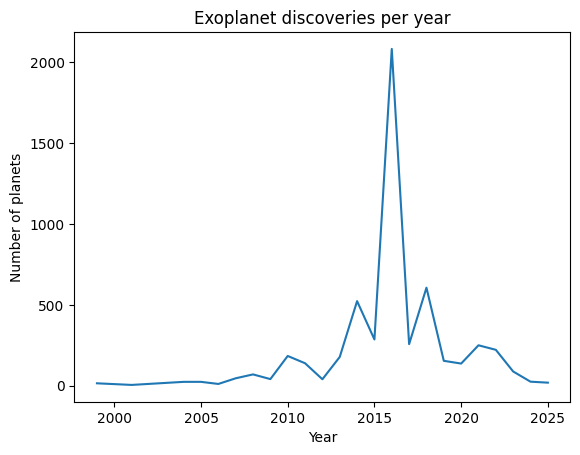

In [ ]:
# =========================================
# Візуалізація даних
# =========================================

print("\n--- Побудова графіка відкриття екзопланет по роках ---")

df['disc_year'].value_counts().sort_index().plot(kind='line')

plt.title("Exoplanet discoveries per year")
plt.xlabel("Year")
plt.ylabel("Number of planets")

plt.show()